# 使用Scikit-Learn 完成預測
### Scikit-Learn在三個面向提供支援。
1. 獲取資料:***klearn.datasets***
2. 掌握資料:***sklearn.preprocessing*** 
3. 機器學習:***sklearn Estimator API*** 

獲取資料的方式有很多種（包含檔案、資料庫、網路爬蟲、Kaggle Datasets等），<br>
其中最簡單的方式是從Sklearn import 內建的資料庫。由於其特性隨手可得且不用下載，所以我們通常叫他**玩具資料**：

# 基本架構

* 讀取資料&pre-processing
* 切分訓練集與測試集 
* 模型配適
* 預測 
* 評估(計算成績可能是誤差值或正確率或..)


In [1]:
%matplotlib inline

from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 讀取Iris資料集與資料前處理

Iris Flowers 資料集

我們在這個項目中使用 Iris Data Set，這個資料集中的每個樣本有4個特徵，1個類別。該資料集1中的樣本類別數為3類，每類樣本數目為50個，總共150個樣本。

屬性資訊：

    花萼長度 sepal length(cm)
    花萼寬度 sepal width(cm)
    花瓣長度 petal length(cm)
    花瓣寬度 petal width(cm)
    類別：
        Iris Setosa
        Iris Versicolour
        Iris Virginica

樣本特徵資料是數值型的，而且單位都相同（釐米）。

![Iris Flowers](images/iris_data.PNG)


In [2]:
iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

* 印出iris的key值與檔案位置
* 查看前10筆資料
* 查看資料型別
* 印出標註的樣本類別資料

In [3]:
print(iris.keys())   #印出iris的key值

print(iris['filename'])  #檔案位置

from pathlib import Path
print(Path(iris['filename']).resolve()) #檔案位置

print(iris.data[0:10])  #查看前10筆資料

print(type(iris.data))  #查看資料型別

print(iris.target)  #印出標註的樣本類別資料

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
iris.csv
C:\Users\terence.lau\Desktop\NTU 469 期 Python機器學習入門\Unit03\iris.csv
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
<class 'numpy.ndarray'>
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [4]:
# we only take the first two features. 

X = iris.data[:,:2]  # 第一個冒號表示所有row，第二個冒號表示column，取前兩個column資料。
print(X.shape)
Y = iris.target
print(Y.shape)

# Remark : these are Upper case X and Y

(150, 2)
(150,)


In [5]:
X   # it is Upper Case X

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6],
       [5.4, 3.9],
       [4.6, 3.4],
       [5. , 3.4],
       [4.4, 2.9],
       [4.9, 3.1],
       [5.4, 3.7],
       [4.8, 3.4],
       [4.8, 3. ],
       [4.3, 3. ],
       [5.8, 4. ],
       [5.7, 4.4],
       [5.4, 3.9],
       [5.1, 3.5],
       [5.7, 3.8],
       [5.1, 3.8],
       [5.4, 3.4],
       [5.1, 3.7],
       [4.6, 3.6],
       [5.1, 3.3],
       [4.8, 3.4],
       [5. , 3. ],
       [5. , 3.4],
       [5.2, 3.5],
       [5.2, 3.4],
       [4.7, 3.2],
       [4.8, 3.1],
       [5.4, 3.4],
       [5.2, 4.1],
       [5.5, 4.2],
       [4.9, 3.1],
       [5. , 3.2],
       [5.5, 3.5],
       [4.9, 3.6],
       [4.4, 3. ],
       [5.1, 3.4],
       [5. , 3.5],
       [4.5, 2.3],
       [4.4, 3.2],
       [5. , 3.5],
       [5.1, 3.8],
       [4.8, 3. ],
       [5.1, 3.8],
       [4.6, 3.2],
       [5.3, 3.7],
       [5. , 3.3],
       [7. , 3.2],
       [6.4, 3.2],
       [6.9,

In [7]:
Y  # it is Upper Case Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [37]:
#以下是組成 pandas DataFrame (也可以不用這種做)
x = pd.DataFrame(iris.data, columns=iris['feature_names'])
x.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [11]:
print("target_name: "+str(iris['target_names']))

target_name: ['setosa' 'versicolor' 'virginica']


In [38]:
#建立Target欄位與資料
y = pd.DataFrame(iris['target'], columns=['target'])
y.head()


,target
0,0
1,0
2,0
3,0
4,0


In [13]:
#合併資料特徵欄位與目標欄位
x = pd.DataFrame(iris.data, columns=iris['feature_names'])
y = pd.DataFrame(iris['target'], columns=['target'])

iris_data = pd.concat([x,y],axis=1)
iris_data.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [14]:
x = pd.DataFrame(iris.data, columns=iris['feature_names'])
y = pd.DataFrame(iris['target'], columns=['target'])

iris_data = pd.concat([x,y],axis=1)

iris_data = iris_data[['sepal length (cm)','petal length (cm)','target']]

iris_data.head(10)

,sepal length (cm),petal length (cm),target
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0
5,5.4,1.7,0
6,4.6,1.4,0
7,5.0,1.5,0
8,4.4,1.4,0
9,4.9,1.5,0


In [49]:
#只選擇目標為0與1的資料
x = pd.DataFrame(iris.data, columns=iris['feature_names'])
y = pd.DataFrame(iris['target'], columns=['target'])

iris_data = pd.concat([x,y],axis=1)


iris_data = iris_data[iris_data['target'].isin([0,1])]

iris_data

print(iris['data'].size)

print(iris['data'].size/len(iris['feature_names']))


600
150.0


## 切分訓練集與測試集
> train_test_split()

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(iris_data[['sepal length (cm)','petal length (cm)']],iris_data[['target']], test_size=0.3)



In [62]:
X_train.head()


,sepal length (cm),petal length (cm)
9,4.9,1.5
23,5.1,1.7
59,5.2,3.9
79,5.7,3.5
21,5.1,1.5


In [63]:
X_train.shape

(70, 2)

In [64]:
X_test.head()

,sepal length (cm),petal length (cm)
30,4.8,1.6
5,5.4,1.7
49,5.0,1.4
29,4.7,1.6
38,4.4,1.3


In [65]:
X_test.shape

(30, 2)

In [66]:
Y_train.head()

,target
9,0
23,0
59,1
79,1
21,0


In [67]:
Y_train.shape

(70, 1)

In [68]:
Y_test.head()

,target
30,0
5,0
49,0
29,0
38,0


In [69]:
Y_test.shape

(30, 1)

# Appendix 

>normalization和standardization是差不多的<br>
都是把數據進行前處理，從而使數值都落入到統一的數值範圍，從而在建模過程中，各個特徵量沒差別對待。<br> 
* normalization一般是把數據限定在需要的範圍，比如一般都是【0，1】，從而消除了數據量綱對建模的影響。<br> 
* standardization 一般是指將數據正態化，使平均值0方差為1.<br> 

因此normalization和standardization 是針對數據而言的，消除一些數值差異帶來的特種重要性偏見。<br>
經過歸一化的數據，能加快訓練速度，促進算法的收斂。

### Standardization (z-score)
    to compute the mean and standard deviation on a training set so as to be able to later reapply the same transformation on the testing set. 

In [76]:
from IPython.display import Math

Math(r'X^{(i)}_{norm}=\frac{X^{(i)}-X_{min}}{X_{max}-X_{min}}')

<IPython.core.display.Math object>

In [74]:
Math(r'X^{(i)}_{std}=\frac{X^{(i)}-\mu_{X}}{\sigma_{X}}')

<IPython.core.display.Math object>

In [77]:
def norm_stats(dfs):
    minimum = np.min(dfs)
    maximum = np.max(dfs)
    mu = np.mean(dfs)
    sigma = np.std(dfs)
    return (minimum, maximum, mu, sigma)  # use Tuple 


def z_score(col, stats):
    m, M, mu, s = stats
    df = pd.DataFrame()
    for c in col.columns:
        df[c] = (col[c]-mu[c])/s[c]
    return df

In [88]:
stats = norm_stats(X_train)    # train data
arr_x_train = np.array(z_score(X_train, stats))
arr_x_train[0:10]  #顯示前10筆資料

C:\Users\terence.lau\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:84: FutureWarning: In a future version, DataFrame.min(axis=None) will return a scalar min over the entire DataFrame. To retain the old behavior, use 'frame.min(axis=0)' or just 'frame.min()'
  return reduction(axis=axis, out=out, **passkwargs)
C:\Users\terence.lau\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:84: FutureWarning: In a future version, DataFrame.max(axis=None) will return a scalar max over the entire DataFrame. To retain the old behavior, use 'frame.max(axis=0)' or just 'frame.max()'
  return reduction(axis=axis, out=out, **passkwargs)
C:\Users\terence.lau\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


array([[-0.98673487, -0.96541293],
       [-0.67489992, -0.82833604],
       [-0.51898245,  0.67950971],
       [ 0.26060492,  0.40535593],
       [-0.67489992, -0.96541293],
       [-1.45448729, -0.96541293],
       [-0.67489992, -0.69125915],
       [-0.05123003,  0.74804815],
       [ 1.81977965,  1.02220192],
       [-1.45448729, -1.30810514]])

In [89]:
stats = norm_stats(X_test)   # test data
arr_x_test = np.array(z_score(X_test, stats))
arr_x_test [0:10]

C:\Users\terence.lau\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:84: FutureWarning: In a future version, DataFrame.min(axis=None) will return a scalar min over the entire DataFrame. To retain the old behavior, use 'frame.min(axis=0)' or just 'frame.min()'
  return reduction(axis=axis, out=out, **passkwargs)
C:\Users\terence.lau\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:84: FutureWarning: In a future version, DataFrame.max(axis=None) will return a scalar max over the entire DataFrame. To retain the old behavior, use 'frame.max(axis=0)' or just 'frame.max()'
  return reduction(axis=axis, out=out, **passkwargs)
C:\Users\terence.lau\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


array([[-0.8666679 , -0.82370813],
       [ 0.12067528, -0.75208134],
       [-0.53755351, -0.96696172],
       [-1.0312251 , -0.82370813],
       [-1.52489669, -1.03858851],
       [-1.36033949, -1.03858851],
       [ 0.12067528,  1.25346889],
       [-0.53755351, -0.82370813],
       [ 0.77890406,  0.96696172],
       [ 1.10801846,  1.25346889]])

In [79]:
stats = norm_stats(X_train)
arr_x_train = np.array(z_score(X_train, stats))
arr_x_train

arr_y_train = np.array(Y_train)

C:\Users\terence.lau\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:84: FutureWarning: In a future version, DataFrame.min(axis=None) will return a scalar min over the entire DataFrame. To retain the old behavior, use 'frame.min(axis=0)' or just 'frame.min()'
  return reduction(axis=axis, out=out, **passkwargs)
C:\Users\terence.lau\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:84: FutureWarning: In a future version, DataFrame.max(axis=None) will return a scalar max over the entire DataFrame. To retain the old behavior, use 'frame.max(axis=0)' or just 'frame.max()'
  return reduction(axis=axis, out=out, **passkwargs)
C:\Users\terence.lau\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


In [25]:
stats = norm_stats(X_train)
arr_x_train = np.array(z_score(X_train, stats))
arr_y_train = np.array(y_train)
arr_x_train[:5]

array([[-0.72966298, -0.79523439],
       [-0.72966298, -1.07013023],
       [ 1.27990064,  1.19776044],
       [ 0.6100461 , -1.07013023],
       [-0.56219935, -0.72651043]])

## use sklearn

In [82]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(X_train)  #Compute the statistics to be used for later scaling.
print(sc.mean_)  #mean
print(sc.scale_) #standard deviation

[5.53285714 2.90857143]
[0.64136493 1.45903519]


In [83]:
#transform: (x-u)/std.
X_train_std = sc.transform(X_train)
X_train_std[:5]

array([[-0.98673487, -0.96541293],
       [-0.67489992, -0.82833604],
       [-0.51898245,  0.67950971],
       [ 0.26060492,  0.40535593],
       [-0.67489992, -0.96541293]])

The scaler instance can then be used on new data to transform it the same way it did on the training set:

In [90]:
X_test_std = sc.transform(X_test)
print(X_test_std[:10])

[[-0.8666679  -0.82370813]
 [ 0.12067528 -0.75208134]
 [-0.53755351 -0.96696172]
 [-1.0312251  -0.82370813]
 [-1.52489669 -1.03858851]
 [-1.36033949 -1.03858851]
 [ 0.12067528  1.25346889]
 [-0.53755351 -0.82370813]
 [ 0.77890406  0.96696172]
 [ 1.10801846  1.25346889]]


you can also use fit_transform method (i.e., fit and then transform)    

In [91]:
X_train_std = sc.fit_transform(X_train)  
X_test_std = sc.fit_transform(X_test)
print(X_test_std[:10])


[[-0.8666679  -0.82370813]
 [ 0.12067528 -0.75208134]
 [-0.53755351 -0.96696172]
 [-1.0312251  -0.82370813]
 [-1.52489669 -1.03858851]
 [-1.36033949 -1.03858851]
 [ 0.12067528  1.25346889]
 [-0.53755351 -0.82370813]
 [ 0.77890406  0.96696172]
 [ 1.10801846  1.25346889]]


In [94]:
# use z-score 把 x train 資料轉換 standard mean to 0, standard deviation is 1

print('mean of X_train_std:',np.round(X_train_std.mean(),4))
print('std of X_train_std:',X_train_std.std())

mean of X_train_std: -0.0
std of X_train_std: 1.0


## Min-Max Normaliaztion
    Transforms features by scaling each feature to a given range.
    The transformation is given by:

    X' = X - X.min(axis=0) / ((X.max(axis=0) - X.min(axis=0))
    X -> N 維資料
    


48.299617438528266
29.717863664628467


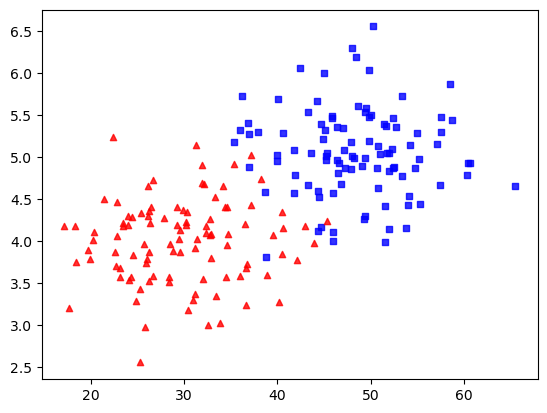

In [97]:
x1 = np.random.normal(50, 6, 100)  # np.random.normal(mu,sigma,size))
y1 = np.random.normal(5, 0.5, 100)

x2 = np.random.normal(30,6,100)
y2 = np.random.normal(4,0.5,100)
plt.scatter(x1,y1,c='b',marker='s',s=20,alpha=0.8)
plt.scatter(x2,y2,c='r', marker='^', s=20, alpha=0.8)

print(np.sum(x1)/len(x1))
print(np.sum(x2)/len(x2))

In [98]:
x_val = np.concatenate((x1,x2))
y_val = np.concatenate((y1,y2))

x_val.shape

(200,)

In [99]:
def minmax_norm(X):
    return (X - X.min(axis=0)) / ((X.max(axis=0) - X.min(axis=0)))

In [36]:
minmax_norm(x_val[:10])

array([0.12277553, 0.93183879, 0.56269276, 0.31105516, 0.34768417,
       0.17620994, 0.        , 0.09094066, 0.15955258, 1.        ])

In [100]:
from sklearn.preprocessing import MinMaxScaler
x_val=x_val.reshape(-1, 1)  #把資料由一個維度 1D 轉為2個維度 2D
scaler = MinMaxScaler().fit(x_val)  # default range 0~1
print(scaler.data_max_)
print(scaler.transform(x_val)[:10])

[65.45017139]
[[0.77758944]
 [0.68392918]
 [0.78155158]
 [0.76248734]
 [0.60768318]
 [0.5945417 ]
 [0.56470379]
 [0.76722978]
 [0.69994284]
 [1.        ]]
